In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Загрузка и предварительный анализ данных
df = pd.read_csv('winequality-red.csv')


# Информация о датасете
print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о столбцах:")
print(df.info())

print("\nОсновные статистические показатели:")
print(df.describe())

Размер датасета: (1599, 12)
Количество строк: 1599
Количество столбцов: 12

Первые 5 строк:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.5


Распределение значений качества вина:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Качество 3: 10 образцов (0.63%)
Качество 4: 53 образцов (3.31%)
Качество 5: 681 образцов (42.59%)
Качество 6: 638 образцов (39.90%)
Качество 7: 199 образцов (12.45%)
Качество 8: 18 образцов (1.13%)

Максимальный класс: 5 (681 образцов)
Минимальный класс: 3 (10 образцов)
Коэффициент дисбаланса: 68.10
ВНИМАНИЕ: Наблюдается значительный дисбаланс классов!


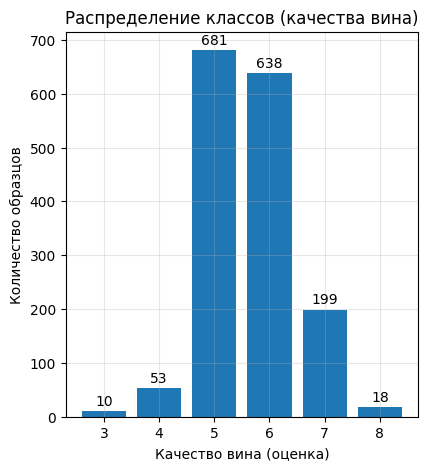

In [5]:
# 2. Анализ целевой переменной (quality)

print("\nРаспределение значений качества вина:")
quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
bars = plt.bar(quality_counts.index, quality_counts.values)
plt.xlabel('Качество вина (оценка)')
plt.ylabel('Количество образцов')
plt.title('Распределение классов (качества вина)')
plt.grid(True, alpha=0.3)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

# Расчет баланса классов
total_samples = len(df)
class_balance = {}
for quality in quality_counts.index:
    percentage = (quality_counts[quality] / total_samples) * 100
    class_balance[quality] = percentage
    print(f"Качество {quality}: {quality_counts[quality]} образцов ({percentage:.2f}%)")

# Проверка сбалансированности
max_count = quality_counts.max()
min_count = quality_counts.min()
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"\nМаксимальный класс: {quality_counts.idxmax()} ({max_count} образцов)")
print(f"Минимальный класс: {quality_counts.idxmin()} ({min_count} образцов)")
print(f"Коэффициент дисбаланса: {imbalance_ratio:.2f}")

if imbalance_ratio > 3:
    print("ВНИМАНИЕ: Наблюдается значительный дисбаланс классов!")
else:
    print("Классы относительно сбалансированы.")

In [9]:
# 3. Подготовка данных для классификации

# Разделение на признаки и целевую переменную
X = df.drop('quality', axis=1)
y = df['quality']

y_bin = label_binarize(y, classes=np.unique(y))

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")

Размер обучающей выборки: 1119 образцов
Размер тестовой выборки: 480 образцов


In [19]:
# 4. Обучение и оценка моделей

# Список моделей для сравнения
models = {
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'Дерево решений': DecisionTreeClassifier(random_state=42, max_depth=5)
}

results = {}

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    # Обучение модели
    model.fit(X_train_scaled, y_train)
    
    # Прогнозирование
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
    
    # Расчет метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (взвешенная): {precision:.4f}")
    print(f"Recall (взвешенная): {recall:.4f}")
    print(f"F1-Score (взвешенный): {f1:.4f}")
    

    print("\nПодробный отчет по классификации:")
    print(classification_report(y_test, y_pred, zero_division=0))


--- kNN ---
Accuracy: 0.5854
Precision (взвешенная): 0.5537
Recall (взвешенная): 0.5854
F1-Score (взвешенный): 0.5676

Подробный отчет по классификации:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.64      0.71      0.67       204
           6       0.55      0.59      0.57       192
           7       0.50      0.38      0.43        60
           8       0.00      0.00      0.00         5

    accuracy                           0.59       480
   macro avg       0.28      0.28      0.28       480
weighted avg       0.55      0.59      0.57       480


--- Дерево решений ---
Accuracy: 0.5646
Precision (взвешенная): 0.5290
Recall (взвешенная): 0.5646
F1-Score (взвешенный): 0.5359

Подробный отчет по классификации:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      


Сравнение моделей:
        Модель  Accuracy  Precision   Recall  F1-Score
           kNN  0.585417   0.553731 0.585417  0.567560
Дерево решений  0.564583   0.529006 0.564583  0.535936


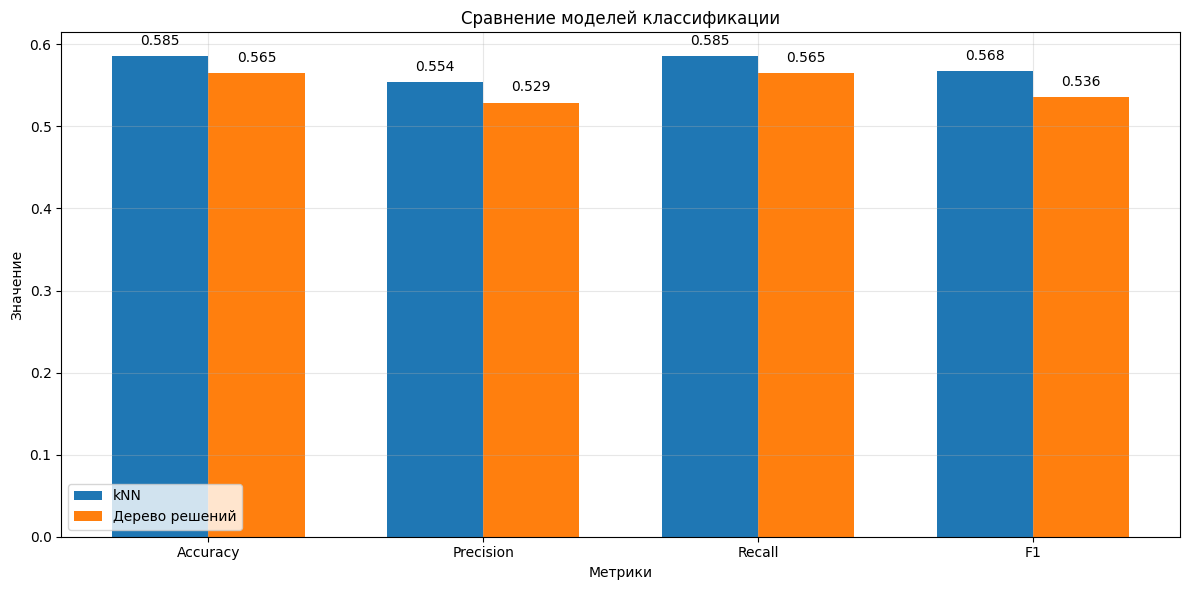

In [17]:
# 5. Сравнение моделей

# Создание таблицы сравнения
comparison_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results]
})

print("\nСравнение моделей:")
print(comparison_df.to_string(index=False))

# Визуализация сравнения метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
for i, model_name in enumerate(results.keys()):
    offset = width * i
    values = [results[model_name][metric.lower()] for metric in metrics]
    rects = ax.bar(x + offset, values, width, label=model_name)
    
    for rect, value in zip(rects, values):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

ax.set_xlabel('Метрики')
ax.set_ylabel('Значение')
ax.set_title('Сравнение моделей классификации')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

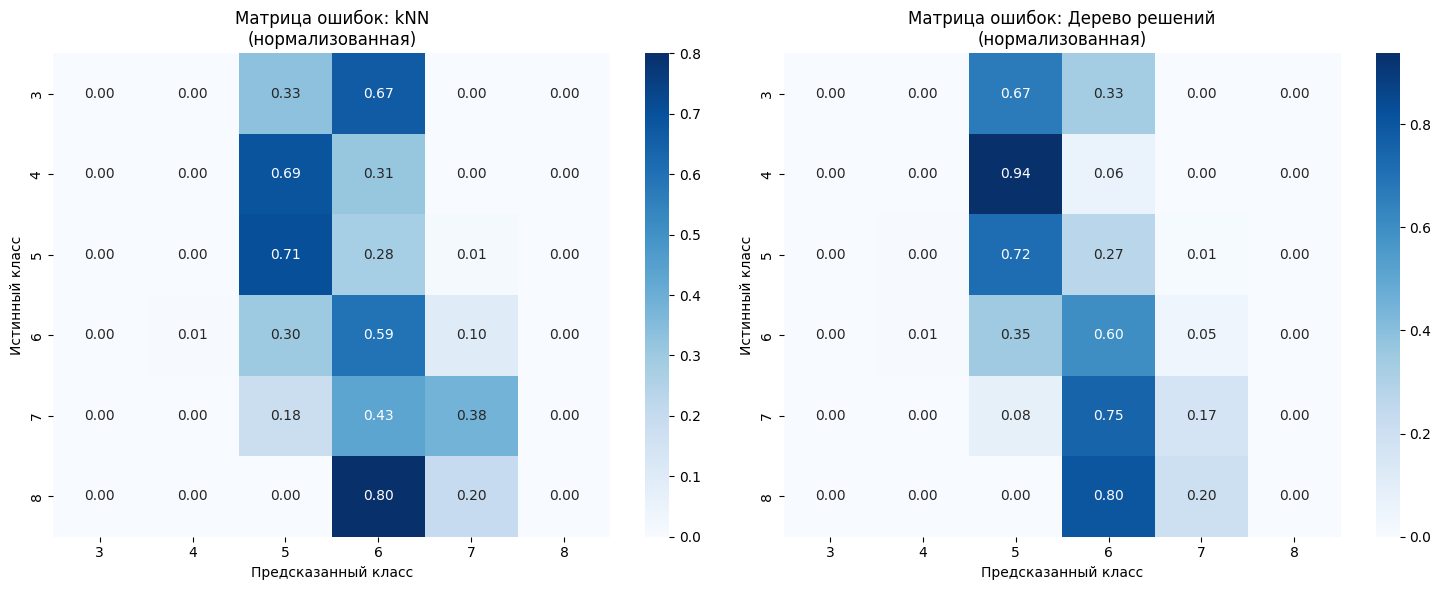

In [21]:
# 6. Матрицы ошибок

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # Нормализация матрицы ошибок
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    ax = axes[idx]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=np.unique(y), yticklabels=np.unique(y), ax=ax)
    ax.set_title(f'Матрица ошибок: {model_name}\n(нормализованная)')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.tight_layout()

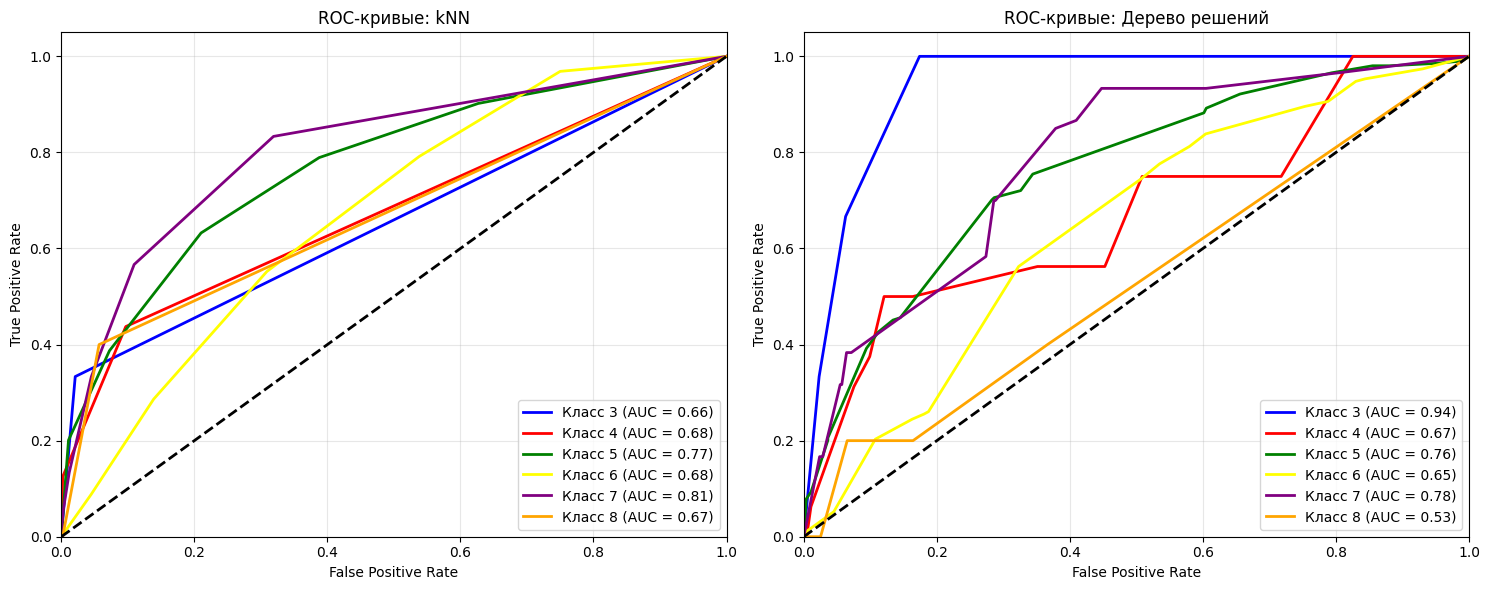

In [25]:
# 7. ROC-кривые

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = cycle(['blue', 'red', 'green', 'yellow', 'purple', 'orange'])

for idx, (model_name, result) in enumerate(results.items()):
    if result['y_pred_proba'] is not None:
        ax = axes[idx]
        
        y_test_bin = label_binarize(y_test, classes=np.unique(y))
        
        # Вычисляем ROC-кривую
        for i, color in zip(range(len(np.unique(y))), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], result['y_pred_proba'][:, i])
            roc_auc = auc(fpr, tpr)
            
            ax.plot(fpr, tpr, color=color, lw=2,
                    label=f'Класс {np.unique(y)[i]} (AUC = {roc_auc:.2f})')
        
        ax.plot([0, 1], [0, 1], 'k--', lw=2)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC-кривые: {model_name}')
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.3)

plt.tight_layout()


Важность признаков в модели дерева решений:
             Признак  Важность
             alcohol  0.423308
           sulphates  0.161986
total sulfur dioxide  0.145786
       fixed acidity  0.104883
    volatile acidity  0.057739
      residual sugar  0.046570
                  pH  0.031659
             density  0.012264
         citric acid  0.008790
           chlorides  0.007016
 free sulfur dioxide  0.000000


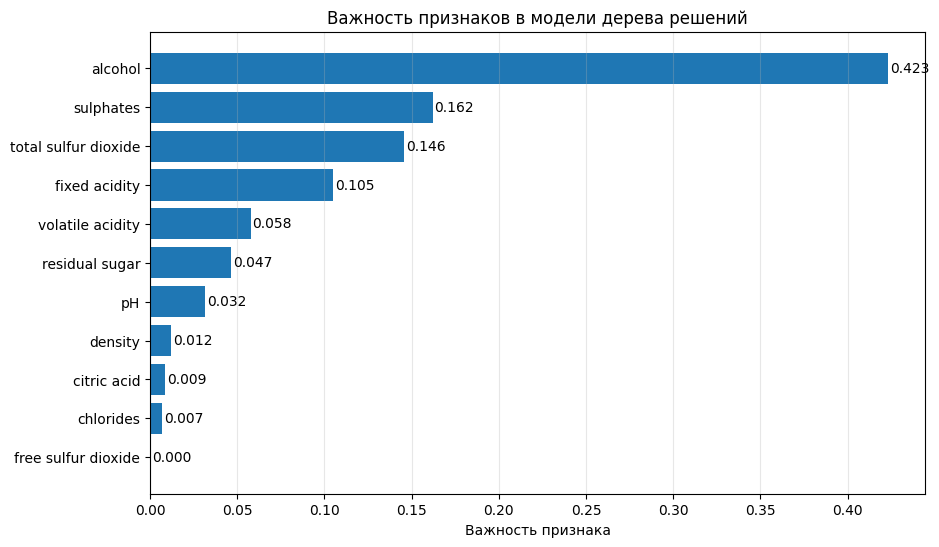

In [27]:
# 8. Важность признаков

if 'Дерево решений' in results:
    tree_model = results['Дерево решений']['model']
    feature_importance = pd.DataFrame({
        'Признак': X.columns,
        'Важность': tree_model.feature_importances_
    }).sort_values('Важность', ascending=False)
    
    print("\nВажность признаков в модели дерева решений:")
    print(feature_importance.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(feature_importance['Признак'], feature_importance['Важность'])
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в модели дерева решений')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
                 f'{width:.3f}', ha='left', va='center')

АНАЛИЗ И ВЫВОДЫ


1. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   - Качество вина (quality) является целевой переменной
   - Диапазон значений: от 3 до 8
   - Наблюдается дисбаланс классов:
     * Наиболее частый класс: 5 и 6 (среднее качество)
     * Наименее частые классы: 3 и 8 (экстремальные оценки)
     * Коэффициент дисбаланса: 68.10

2. СРАВНЕНИЕ АЛГОРИТМОВ:
   - Лучшая модель по Accuracy: kNN (0.5854)

3. ОБЪЯСНЕНИЕ РЕЗУЛЬТАТОВ:
   - kNN:
     * Преимущества: Простота реализации, нет предположений о данных
     * Недостатки: Чувствителен к масштабированию, медленный на больших данных
     * Результаты: Может страдать при дисбалансе классов

   - Дерево решений:
     * Преимущества: Интерпретируемость, работа с категориальными данными
     * Недостатки: Склонность к переобучению, чувствительность к шуму
     * Результаты: Часто показывает хорошие результаты на структурированных данных